# Illegal Mining Detection — CNN Training (PyTorch)
**Project:** Detection of Illegal Mining Using Satellite Imagery and CNN  
**Notebook:** `train_cnn_model.ipynb`  
**Stage:** 2 of 3 — Dataset Preparation & Model Training

Pipeline:
1. `extract_patches.ipynb` ✅ Done
2. `train_cnn_model.ipynb` ← **You are here**
3. `temporal_analysis.ipynb` → Next

## Cell 1 — Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB


## Cell 2 — Dataset Paths & Settings

In [2]:
# UPDATE THIS PATH TO YOUR ACTUAL DATASET LOCATION
DATASET_PATH = r"R:\ai project image\cnn dataset"

# Expected folder structure:
# cnn dataset/
#   mining/
#   non_mining/

# Hyperparameters
IMAGE_SIZE    = 64
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 0.001
RANDOM_SEED   = 42

# Split ratios (train 70% | val 15% | test 15%)
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

MODEL_SAVE_PATH = 'saved_models/custom_cnn.pth'
os.makedirs('saved_models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

torch.manual_seed(RANDOM_SEED)

print('Dataset path:', DATASET_PATH)
print('Classes:', os.listdir(DATASET_PATH))

Dataset path: R:\ai project image\cnn dataset
Classes: ['mining', 'non mining']


## Cell 3 — Data Transforms & Load Dataset

In [3]:
# Training transform — with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation & Test transform — NO augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=val_test_transform)

print('Classes:', full_dataset.classes)
print('Class indices:', full_dataset.class_to_idx)
print('Total images:', len(full_dataset))

Classes: ['mining', 'non mining']
Class indices: {'mining': 0, 'non mining': 1}
Total images: 2955


## Cell 4 — Split into Train / Val / Test

In [4]:
total_size = len(full_dataset)
train_size = int(TRAIN_SPLIT * total_size)
val_size   = int(VAL_SPLIT   * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Apply augmentation to training set only
train_dataset.dataset.transform = train_transform

print(f'Train size : {len(train_dataset)}')
print(f'Val size   : {len(val_dataset)}')
print(f'Test size  : {len(test_dataset)}')

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('DataLoaders created successfully!')

Train size : 2068
Val size   : 443
Test size  : 444
DataLoaders created successfully!


## Cell 5 — Build Custom CNN Model

In [5]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 64 -> 32
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32 -> 16
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16 -> 8
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = CustomCNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

CustomCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_feat

## Cell 6 — Loss Function & Optimizer

In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Reduce learning rate if val_loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5, verbose=True
)

print('Loss     : Binary Cross Entropy')
print('Optimizer: Adam (lr={:.4f})'.format(LEARNING_RATE))
print('Scheduler: ReduceLROnPlateau (patience=3)')

Loss     : Binary Cross Entropy
Optimizer: Adam (lr=0.0010)
Scheduler: ReduceLROnPlateau (patience=3)


c:\Users\Rohit Bansal\anaconda3\envs\mining_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Cell 7 — Train the Model

In [7]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0
EARLY_STOP_PATIENCE = 5

for epoch in range(EPOCHS):

    # TRAINING PHASE
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        preds          = (outputs > 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    # VALIDATION PHASE
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs     = model(images)
            loss        = criterion(outputs, labels)
            val_loss   += loss.item() * images.size(0)
            preds       = (outputs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    # CALCULATE EPOCH METRICS
    epoch_train_loss = train_loss / train_total
    epoch_val_loss   = val_loss   / val_total
    epoch_train_acc  = train_correct / train_total
    epoch_val_acc    = val_correct   / val_total

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f'Epoch [{epoch+1:02d}/{EPOCHS}] '
          f'Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | '
          f'Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')

    # SAVE BEST MODEL
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f'  >> Best model saved (Val Acc: {best_val_acc:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1

    # EARLY STOPPING
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

    scheduler.step(epoch_val_loss)

print(f'Training complete! Best Val Accuracy: {best_val_acc:.4f}')

Epoch [01/20] Train Loss: 0.5391 | Train Acc: 0.7824 | Val Loss: 0.3940 | Val Acc: 0.8126
  >> Best model saved (Val Acc: 0.8126)
Epoch [02/20] Train Loss: 0.3403 | Train Acc: 0.8540 | Val Loss: 0.3006 | Val Acc: 0.8758
  >> Best model saved (Val Acc: 0.8758)
Epoch [03/20] Train Loss: 0.3232 | Train Acc: 0.8641 | Val Loss: 0.2520 | Val Acc: 0.9029
  >> Best model saved (Val Acc: 0.9029)
Epoch [04/20] Train Loss: 0.2875 | Train Acc: 0.8835 | Val Loss: 0.3429 | Val Acc: 0.8849
Epoch [05/20] Train Loss: 0.2834 | Train Acc: 0.8965 | Val Loss: 0.2161 | Val Acc: 0.9187
  >> Best model saved (Val Acc: 0.9187)
Epoch [06/20] Train Loss: 0.2737 | Train Acc: 0.8931 | Val Loss: 0.2330 | Val Acc: 0.9007
Epoch [07/20] Train Loss: 0.2735 | Train Acc: 0.8989 | Val Loss: 0.2046 | Val Acc: 0.9278
  >> Best model saved (Val Acc: 0.9278)
Epoch [08/20] Train Loss: 0.2576 | Train Acc: 0.9081 | Val Loss: 0.2280 | Val Acc: 0.8984
Epoch [09/20] Train Loss: 0.2554 | Train Acc: 0.8931 | Val Loss: 0.1888 | Val Ac

## Cell 8 — Plot Training Results

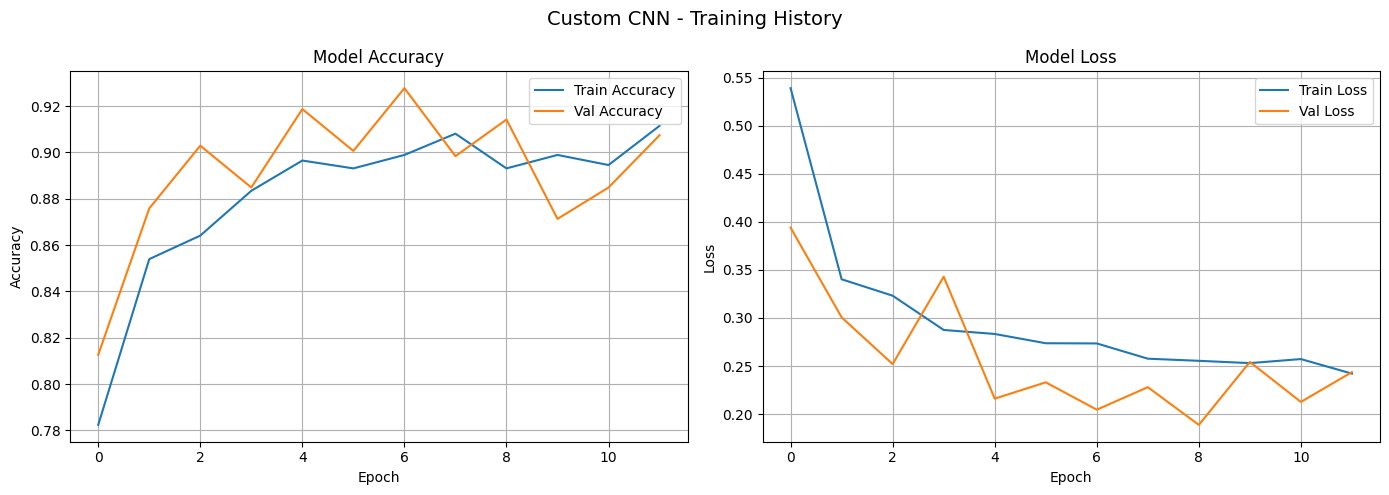

Plot saved to plots/custom_cnn_training.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train Accuracy')
axes[0].plot(history['val_acc'],   label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'],   label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Custom CNN - Training History', fontsize=14)
plt.tight_layout()
plt.savefig('plots/custom_cnn_training.png', dpi=150)
plt.show()
print('Plot saved to plots/custom_cnn_training.png')

## Cell 9 — Evaluate on Test Set

In [9]:
# Load best saved model
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        preds   = (outputs > 0.5).float().squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f}')

class_names = full_dataset.classes
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 0.9167

Classification Report:
              precision    recall  f1-score   support

      mining       0.93      0.84      0.88       165
  non mining       0.91      0.96      0.94       279

    accuracy                           0.92       444
   macro avg       0.92      0.90      0.91       444
weighted avg       0.92      0.92      0.92       444



## Cell 10 — Confusion Matrix

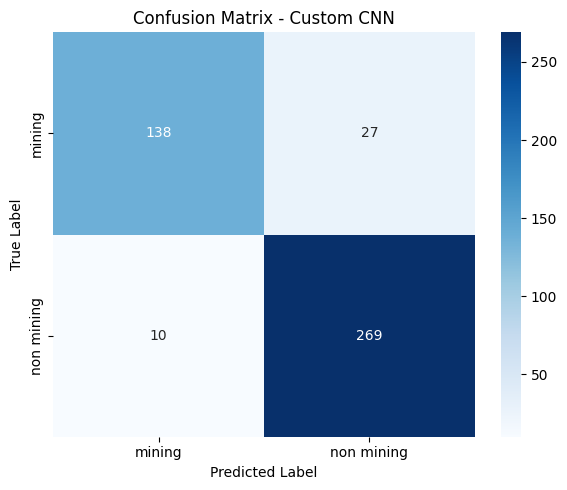

Confusion matrix saved to plots/custom_cnn_confusion_matrix.png


In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - Custom CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plots/custom_cnn_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved to plots/custom_cnn_confusion_matrix.png')

## Cell 11 — Summary

In [11]:
print('Best model saved at :', MODEL_SAVE_PATH)
print('File size           :', round(os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024, 2), 'MB')
print('Device used         :', device)
print('Best Val Accuracy   :', round(best_val_acc, 4))
print('Test Accuracy       :', round(test_acc, 4))
print('')
print('Next step -> open temporal_analysis.ipynb')
print('That notebook will:')
print('  1. Load this saved model')
print('  2. Run it on year-wise patches for each site')
print('  3. Count mining patches per year')
print('  4. Plot mining area vs year')
print('  5. Estimate risk level based on growth rate')

Best model saved at : saved_models/custom_cnn.pth
File size           : 4.37 MB
Device used         : cuda
Best Val Accuracy   : 0.9278
Test Accuracy       : 0.9167

Next step -> open temporal_analysis.ipynb
That notebook will:
  1. Load this saved model
  2. Run it on year-wise patches for each site
  3. Count mining patches per year
  4. Plot mining area vs year
  5. Estimate risk level based on growth rate


In [14]:
# Re-run inference to get probabilities for AUC
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_probs  = []
all_labels_auc = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)          # sigmoid output, shape (N, 1)
        probs   = outputs.squeeze(1).cpu().numpy()   # raw probabilities
        all_probs.extend(probs)
        all_labels_auc.extend(labels.numpy())

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(all_labels_auc, all_probs)
print(f'Custom CNN AUC-ROC: {auc:.4f}')

Custom CNN AUC-ROC: 0.9741
